In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving VD_HCC.xlsx to VD_HCC.xlsx


In [5]:
path = "VD_HCC.xlsx"
df = pd.read_excel(path, sheet_name = 'VD_HCC')
data = df.copy()
data.columns

Index(['record_id', 'Age', 'Gender', 'Platelets', 'INR', 'AST', 'ALT',
       'Total_Bil', 'Dir_Bil', 'Albumin', 'Ure', 'Creatinine', 'Glucose',
       'HBsAg', 'HCVAb', 'CEA', 'AFP', 'CA19-9', 'AST/ALT', 'APRI', 'FIB-4',
       'label'],
      dtype='object')

In [6]:
selected_columns = ['Age', 'Gender', 'Platelets', 'INR', 'AST', 'ALT',
       'Total_Bil', 'Dir_Bil', 'Albumin', 'Ure', 'Creatinine', 'Glucose',
       'HBsAg', 'HCVAb', 'CEA', 'AFP', 'CA19-9', 'AST/ALT', 'APRI', 'FIB-4']

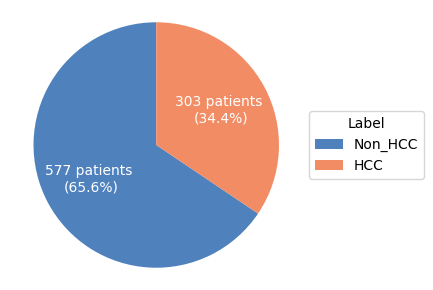

In [10]:
label_counts = df['label'].value_counts()

labels = ['Non_HCC', 'HCC']
colors = ['#4F81BD', '#F28C64']

def func(pct, allvalues):
    absolute = int(pct / 100. * sum(allvalues))
    return f"{absolute:d} patients \n({pct:.1f}%)"

# Tăng nhẹ chiều ngang để có không gian chứa legend bên phải
plt.figure(figsize=(4.5, 3))

plt.pie(
    label_counts,
    labels=None,
    autopct=lambda pct: func(pct, label_counts),
    startangle=90,
    colors=colors,
    textprops={'fontsize': 10, 'color': 'white'}
)

plt.legend(
    labels,
    title="Label",
    loc="center left",
    bbox_to_anchor=(1, 0, 0, 1),
    fontsize=10,
    title_fontsize=10
)

plt.axis('equal')

plt.subplots_adjust(top=0.95, bottom=0.05, left=0.0, right=0.65)

plt.show()

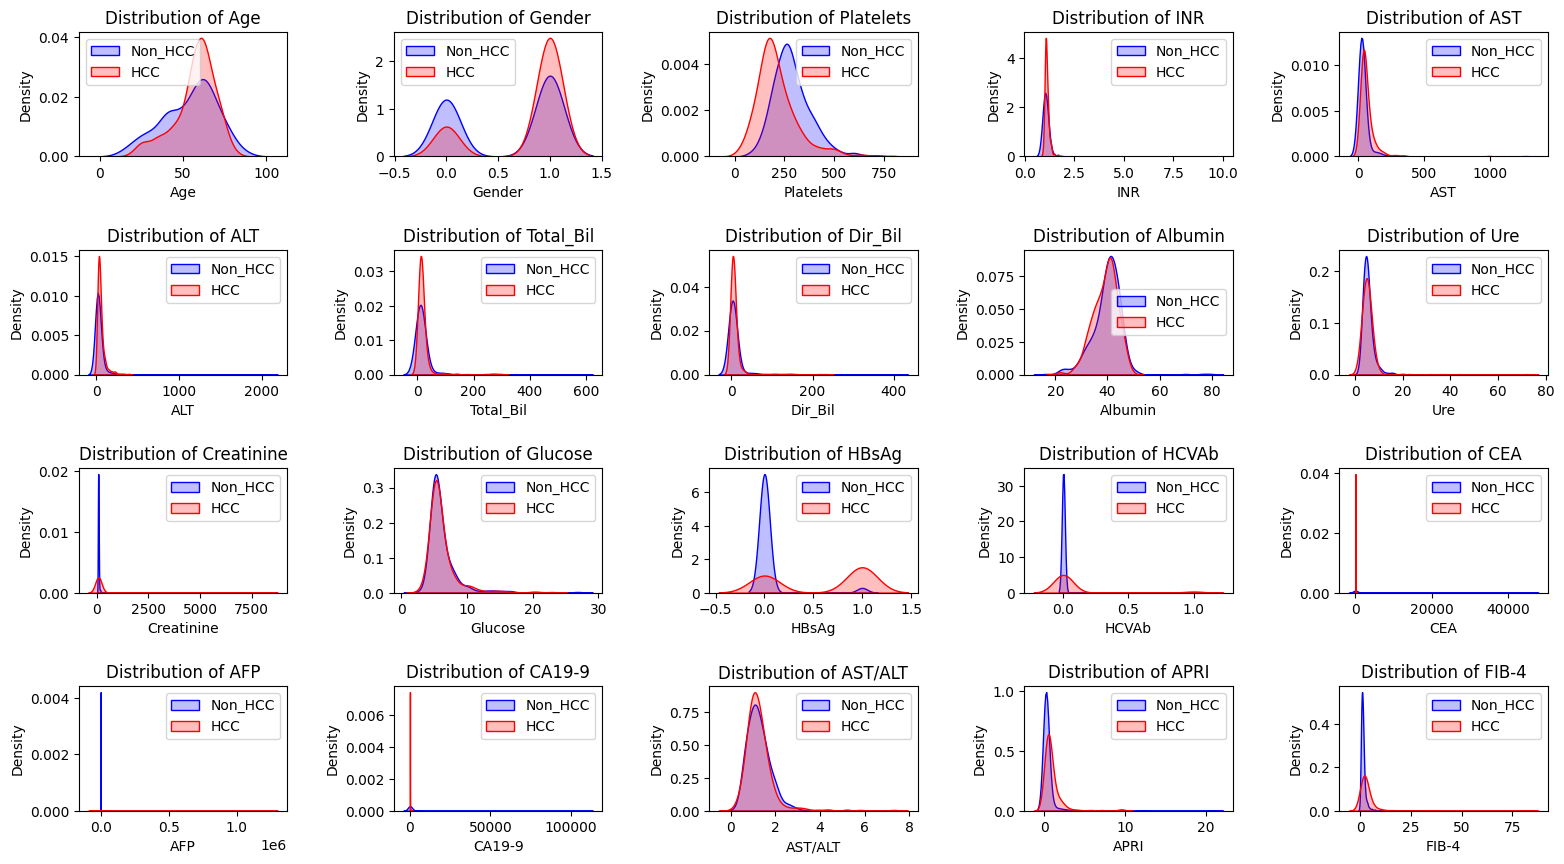

In [ ]:
plt.figure(figsize=(16, 9))
for i, metric in enumerate(selected_columns,1):
    plt.subplot(4,5,i)
    sns.kdeplot(data[data['label'] == 0][metric], fill = True, color = 'blue', label = 'Non_HCC', warn_singular=False)
    sns.kdeplot(data[data['label'] == 1][metric], fill = True, color = 'red', label = 'HCC')
    plt.title(f'Distribution of {metric}')
    plt.legend(loc = 'best')
plt.tight_layout(pad=2.0)
plt.show()